In [490]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler, StandardScaler
from scipy.sparse import hstack
import math

In [491]:
df = pd.read_csv("song_recomendation_B.csv")

# EXPLORATORY DATA ANALYSIS

In [492]:
df.head()

,Track URI,Track Name,Artist Name(s),Album Name,Album Release Date,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,spotify:track:6a8GbQIlV8HBUW3c6Uk9PH,I Know You Want Me (Calle Ocho),Pitbull,Pitbull Starring In Rebelution,2009-10-23,64,"dance pop,miami hip hop,pop",0.825,0.743,2.0,-5.995,1.0,0.1490,0.0142,0.000021,0.2370,0.800,127.045,4.0
1,spotify:track:70XtWbcVZcpaOddJftMcVi,From the Bottom of My Broken Heart,Britney Spears,...Baby One More Time (Digital Deluxe Version),1999-01-12,56,"dance pop,pop",0.677,0.665,7.0,-5.171,1.0,0.0305,0.5600,NaN,0.3380,0.706,74.981,4.0
2,spotify:track:72WZtWs6V7uu3aMgMmEkYe,You Can't Always Get What You Want,The Rolling Stones,Let It Bleed,1969-12-05,0,"album rock,british invasion,classic rock,rock",0.319,0.627,0.0,-9.611,1.0,0.0687,0.6750,0.000073,0.2890,0.497,85.818,4.0
3,spotify:track:4bEb3KE4mSKlTFjtWJQBqO,Don't Stop - 2004 Remaster,Fleetwood Mac,Rumours,1977-02-04,79,"album rock,classic rock,rock,soft rock,yacht rock",0.671,0.710,9.0,-7.724,1.0,0.0356,0.0393,0.000011,0.0387,0.834,118.745,4.0
4,spotify:track:0d2iYfpKoM0QCKvcLCkBao,Eastside (with Halsey & Khalid),"benny blanco, Halsey, Khalid",Eastside (with Halsey & Khalid),2018-07-12,78,"pop,electropop,etherpop,indie poptimism,pop,po...",0.560,0.680,6.0,-7.648,0.0,0.3210,0.5550,0.000000,0.1160,0.319,89.391,4.0


In [493]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track URI           4999 non-null   object 
 1   Track Name          4999 non-null   object 
 2   Artist Name(s)      4999 non-null   object 
 3   Album Name          4999 non-null   object 
 4   Album Release Date  4997 non-null   object 
 5   Popularity          4999 non-null   int64  
 6   Artist Genres       4744 non-null   object 
 7   Danceability        4747 non-null   float64
 8   Energy              4997 non-null   float64
 9   Key                 4997 non-null   float64
 10  Loudness            4997 non-null   float64
 11  Mode                4997 non-null   float64
 12  Speechiness         4997 non-null   float64
 13  Acousticness        4997 non-null   float64
 14  Instrumentalness    4897 non-null   float64
 15  Liveness            4997 non-null   float64
 16  Valenc

The dataset contains 18 columns about keys that a film has. From those columns, I'll see the insight from each column.

In [494]:
df.isna().sum()

Track URI               0
Track Name              0
Artist Name(s)          0
Album Name              0
Album Release Date      2
Popularity              0
Artist Genres         255
Danceability          252
Energy                  2
Key                     2
Loudness                2
Mode                    2
Speechiness             2
Acousticness            2
Instrumentalness      102
Liveness                2
Valence                 2
Tempo                   2
Time Signature          2
dtype: int64

There are 2 null values for some columns. The solution is filling it with blank string "" for categorical columns and 0 for numerical columns.

In [495]:
df.duplicated().sum()

13

13 duplicated values have to be deleted by dropping them. They have to be dropped because has a potential to make noises while modelling.

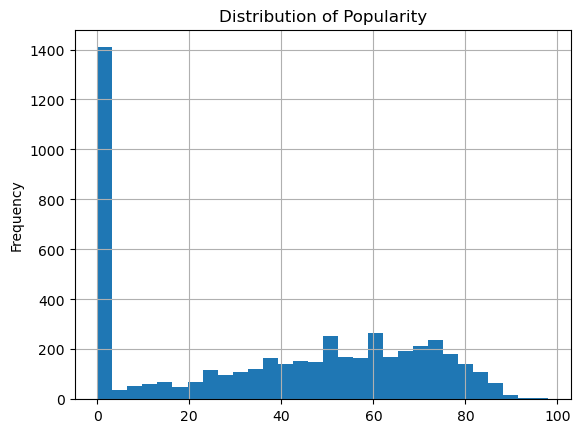

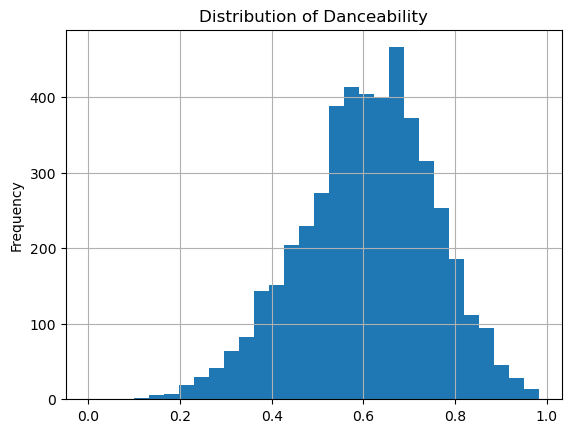

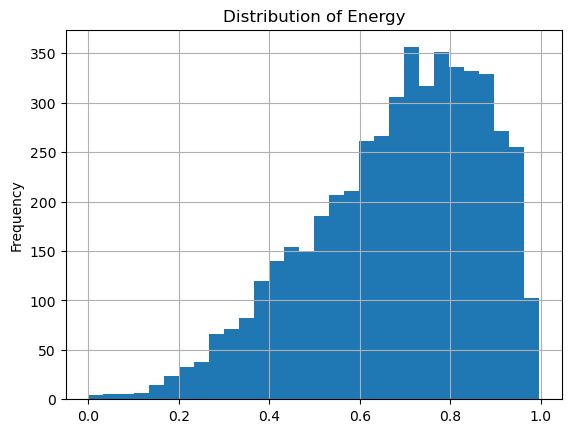

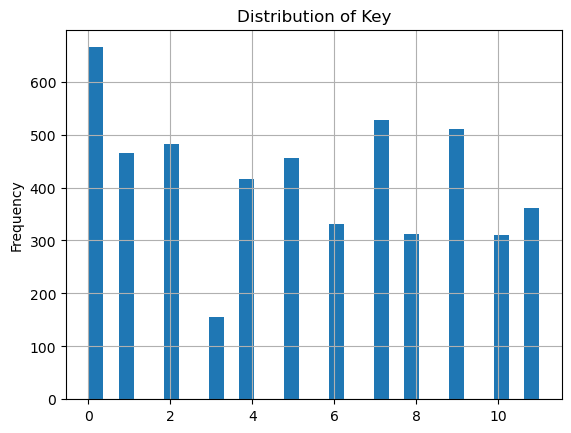

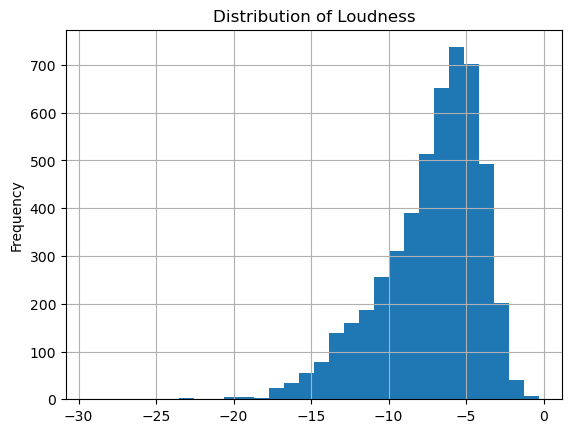

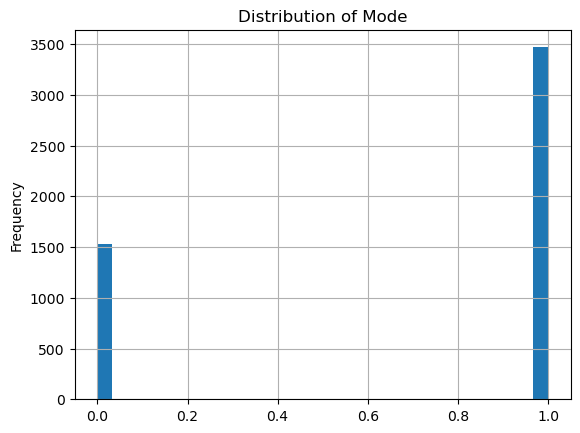

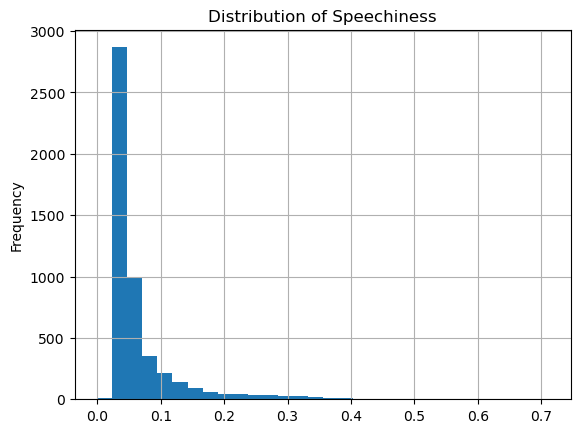

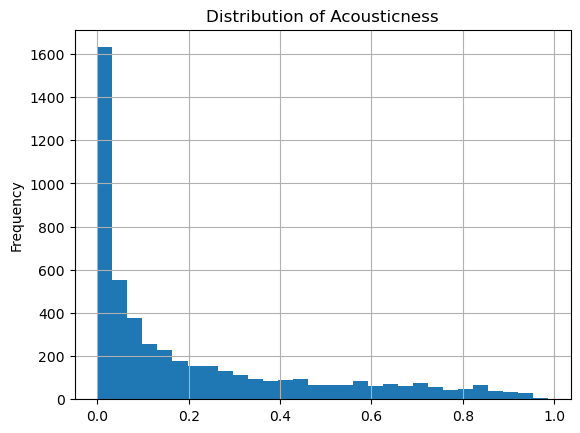

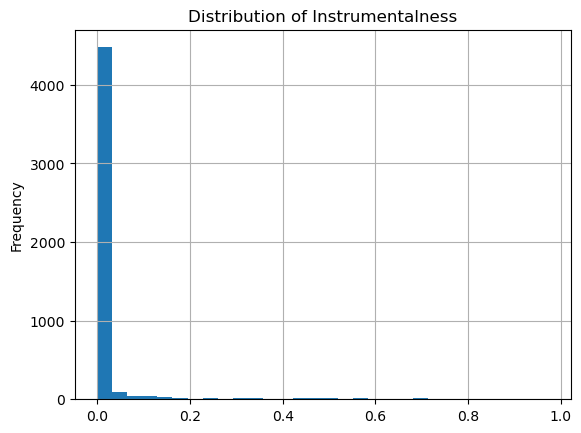

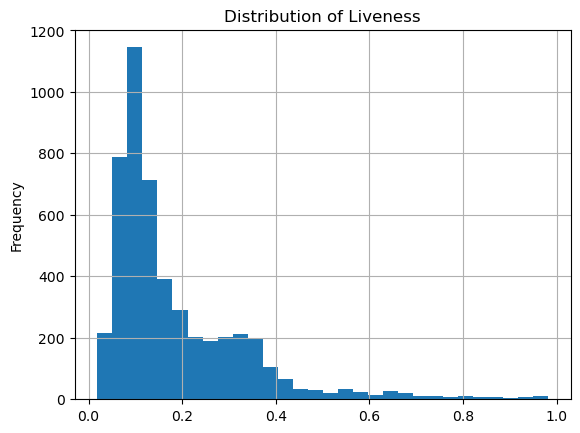

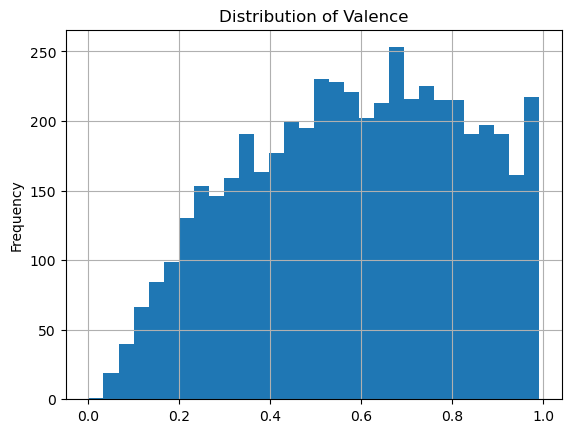

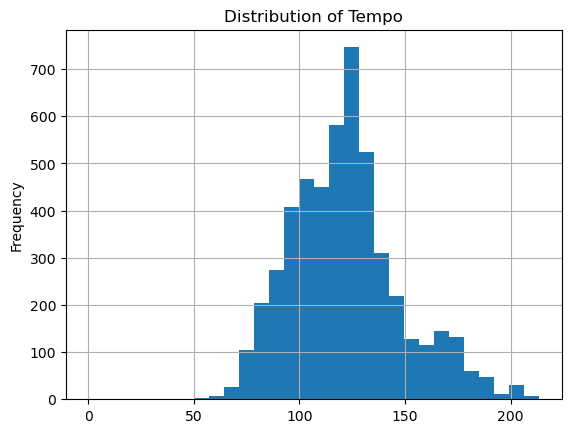

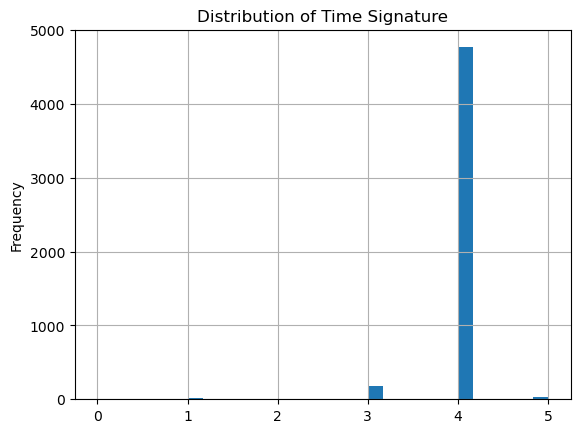

In [496]:
num_col = df.select_dtypes(exclude=object).columns

for i in num_col:
    df[i].dropna().hist(bins = 30)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {i}")
    plt.show()

1. The popularity shows that most of the music in the spotify dataset has a scale 0 of 100. This means based on recent track, most of the songs doesn't have any popularities.

2. Danceability diagram shows that most of the track is suitable for dancing with the score 0.6 of 1.0. The score means that most of the songs are likely made only to be heard by people and consume other stuffs beside dancing.

3. The distribution of energy shows that the intensity and activity for the most of the song is likely high. This means that most of the songs have speed and volume higher than ordinary music.

4. The Loudness distribution shows that most of the song have a little turned down volume and indicating that the music is not too loud.

5. The speechiness is not far away from 0.0, which means that most of the songs have a few lyrics.

6. Acoustic doesn't get too far from 0, which means that most of the songs are not acoustic.

7. The instrumentalness distribution shows that most of the musics likely have their own vocals

8. The liveness score mostly around 0.1. This means that most songs didn't record in front of the audience.

9. Distribution of Valence shows that most songs share happiness to their listener because their songs have a positive vibes.

10. The temp of the songs mostly around 100-150 bpm, which is a normal pace for a song. Not too fast, but also not too slow.

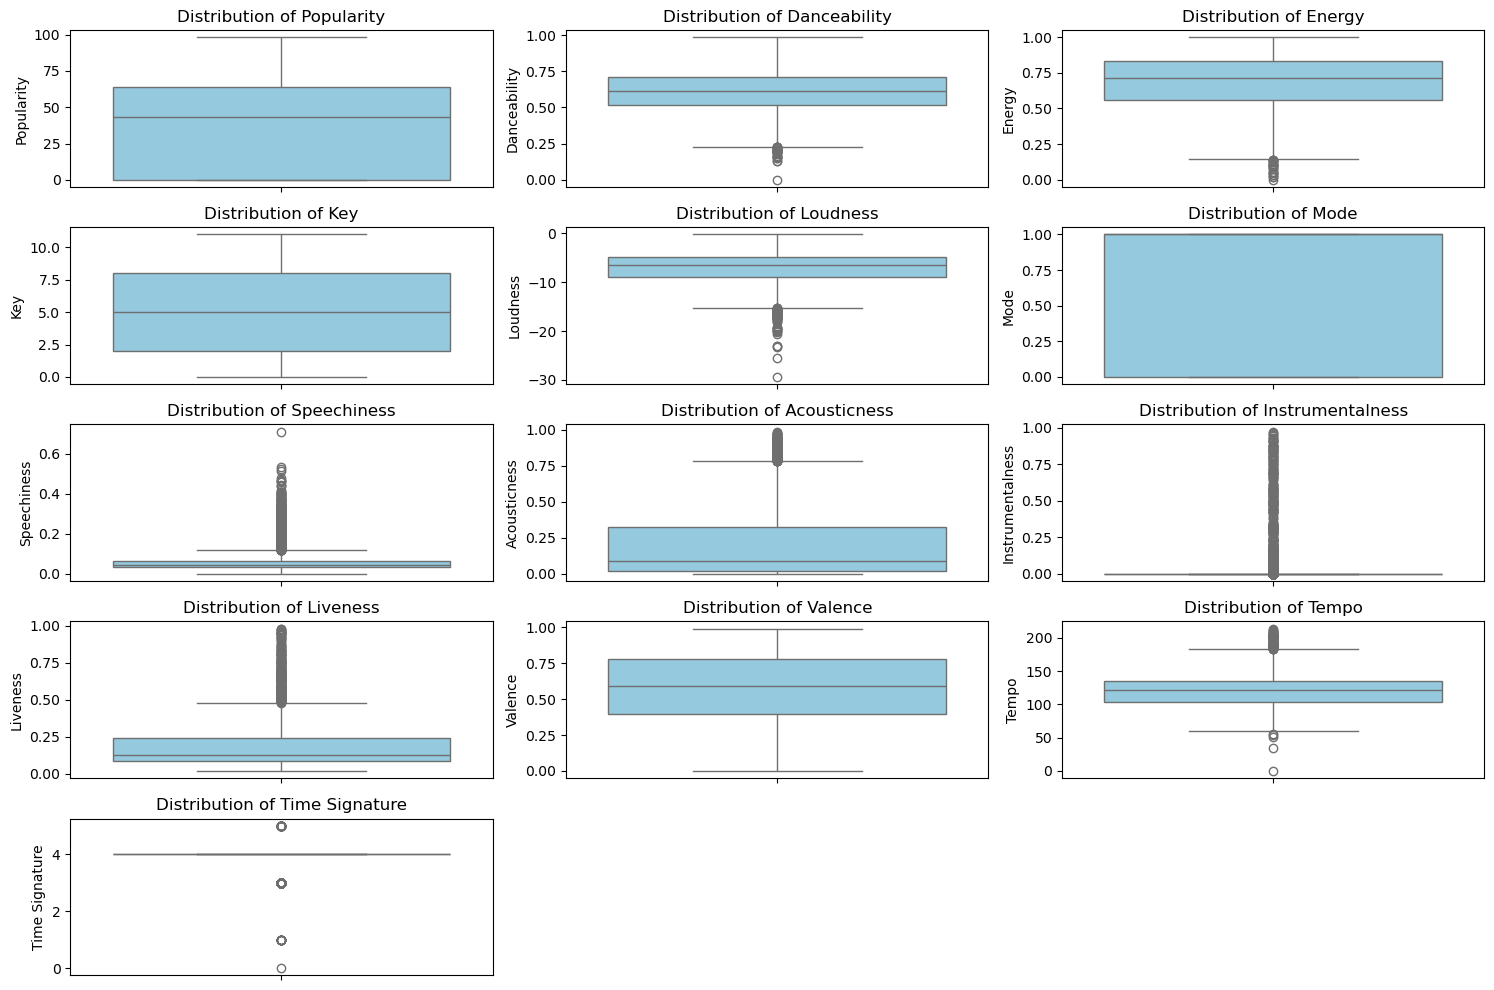

In [497]:
n_rows = math.ceil(len(num_col)/3)
fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(15, n_rows * 2))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.boxplot(data=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Majority columns have extreme outliers. To handle them, robust scaler will be used because it is use median as the main component and ignore the extreme value that a column have.

## Data Cleaning

In [498]:
df_clean = df.copy()

In [499]:
df_clean.duplicated().sum()

13

In [500]:
df_clean.drop_duplicates(inplace=True)

In [501]:
df_clean.isna().sum()

Track URI               0
Track Name              0
Artist Name(s)          0
Album Name              0
Album Release Date      2
Popularity              0
Artist Genres         255
Danceability          252
Energy                  2
Key                     2
Loudness                2
Mode                    2
Speechiness             2
Acousticness            2
Instrumentalness      102
Liveness                2
Valence                 2
Tempo                   2
Time Signature          2
dtype: int64

In [502]:
cat_col = df_clean.select_dtypes(include=object).columns
num_col = df_clean.select_dtypes(exclude=object).columns

for i in cat_col:
    df_clean[i] = df_clean[i].fillna("")

for i in num_col:
    df_clean[i] = df_clean[i].fillna(0)

In [503]:
df_clean.isna().sum()

Track URI             0
Track Name            0
Artist Name(s)        0
Album Name            0
Album Release Date    0
Popularity            0
Artist Genres         0
Danceability          0
Energy                0
Key                   0
Loudness              0
Mode                  0
Speechiness           0
Acousticness          0
Instrumentalness      0
Liveness              0
Valence               0
Tempo                 0
Time Signature        0
dtype: int64

## Feature Engineering

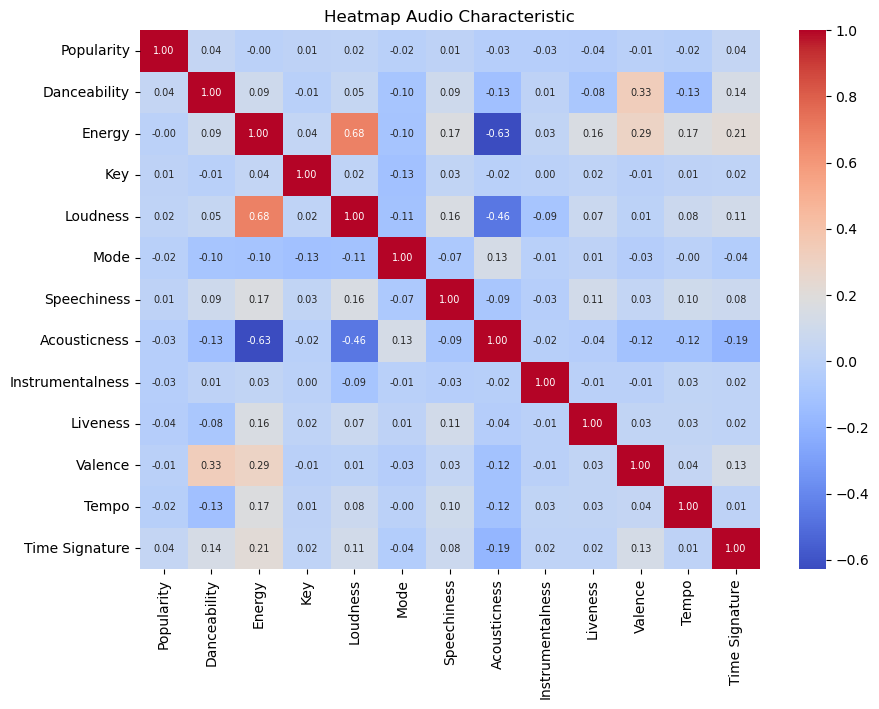

In [504]:
num_col = df_clean.select_dtypes(exclude=object).columns
cat_col = df_clean.select_dtypes(include=object).columns

plt.figure(figsize=(10, 7))
sns.heatmap(df_clean[num_col].corr(), annot=True, fmt=".2f", annot_kws={"size": 7}, cmap='coolwarm')
plt.title('Heatmap Audio Characteristic')
plt.show()

In [505]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4986 entries, 0 to 4998
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track URI           4986 non-null   object 
 1   Track Name          4986 non-null   object 
 2   Artist Name(s)      4986 non-null   object 
 3   Album Name          4986 non-null   object 
 4   Album Release Date  4986 non-null   object 
 5   Popularity          4986 non-null   int64  
 6   Artist Genres       4986 non-null   object 
 7   Danceability        4986 non-null   float64
 8   Energy              4986 non-null   float64
 9   Key                 4986 non-null   float64
 10  Loudness            4986 non-null   float64
 11  Mode                4986 non-null   float64
 12  Speechiness         4986 non-null   float64
 13  Acousticness        4986 non-null   float64
 14  Instrumentalness    4986 non-null   float64
 15  Liveness            4986 non-null   float64
 16  Valence    

In [506]:
for i in cat_col:
    print(f"{i}: ", df_clean[i].nunique())

Track URI:  4985
Track Name:  4476
Artist Name(s):  2597
Album Name:  3854
Album Release Date:  2194
Artist Genres:  1866


In this project, I'll use Artists Genres, Album Release Date (Year), and Track Name. Track URI, Artists Name, and Album Name would not be used.

In [507]:
df_clean = df_clean.drop(['Track URI'], axis = 1)

In [508]:
df_clean.head()

,Track Name,Artist Name(s),Album Name,Album Release Date,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,I Know You Want Me (Calle Ocho),Pitbull,Pitbull Starring In Rebelution,2009-10-23,64,"dance pop,miami hip hop,pop",0.825,0.743,2.0,-5.995,1.0,0.1490,0.0142,0.000021,0.2370,0.800,127.045,4.0
1,From the Bottom of My Broken Heart,Britney Spears,...Baby One More Time (Digital Deluxe Version),1999-01-12,56,"dance pop,pop",0.677,0.665,7.0,-5.171,1.0,0.0305,0.5600,0.000000,0.3380,0.706,74.981,4.0
2,You Can't Always Get What You Want,The Rolling Stones,Let It Bleed,1969-12-05,0,"album rock,british invasion,classic rock,rock",0.319,0.627,0.0,-9.611,1.0,0.0687,0.6750,0.000073,0.2890,0.497,85.818,4.0
3,Don't Stop - 2004 Remaster,Fleetwood Mac,Rumours,1977-02-04,79,"album rock,classic rock,rock,soft rock,yacht rock",0.671,0.710,9.0,-7.724,1.0,0.0356,0.0393,0.000011,0.0387,0.834,118.745,4.0
4,Eastside (with Halsey & Khalid),"benny blanco, Halsey, Khalid",Eastside (with Halsey & Khalid),2018-07-12,78,"pop,electropop,etherpop,indie poptimism,pop,po...",0.560,0.680,6.0,-7.648,0.0,0.3210,0.5550,0.000000,0.1160,0.319,89.391,4.0


In [509]:
df_clean['Album Release Date'] = pd.to_datetime(df_clean['Album Release Date'], errors='coerce')
df_clean['Release_Year'] = df_clean['Album Release Date'].dt.year
df_clean['Release_Year'] = df_clean['Release_Year'].fillna(0)
df_clean = df_clean.drop('Album Release Date', axis = 1)


In [510]:
df_clean['Artist Genres'] = df_clean['Artist Genres'].apply(lambda x: [g.strip() for g in str(x).split(',')] if pd.notnull(x) else [])

tfidf = TfidfVectorizer(
    tokenizer=lambda x: x,
    lowercase=False,
    token_pattern=None
)

genre_tfidf = tfidf.fit_transform(df_clean['Artist Genres'])

In [511]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4986 entries, 0 to 4998
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track Name        4986 non-null   object 
 1   Artist Name(s)    4986 non-null   object 
 2   Album Name        4986 non-null   object 
 3   Popularity        4986 non-null   int64  
 4   Artist Genres     4986 non-null   object 
 5   Danceability      4986 non-null   float64
 6   Energy            4986 non-null   float64
 7   Key               4986 non-null   float64
 8   Loudness          4986 non-null   float64
 9   Mode              4986 non-null   float64
 10  Speechiness       4986 non-null   float64
 11  Acousticness      4986 non-null   float64
 12  Instrumentalness  4986 non-null   float64
 13  Liveness          4986 non-null   float64
 14  Valence           4986 non-null   float64
 15  Tempo             4986 non-null   float64
 16  Time Signature    4986 non-null   float64
 17  

In [512]:
robust_columns = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Time Signature']
standard_columns = ['Valence']
preprocessor = ColumnTransformer([
    ('robust', RobustScaler(), robust_columns),
    ('standard', StandardScaler(), standard_columns)
])

audio_scaled = preprocessor.fit_transform(df_clean)

In [513]:
X = hstack([
    genre_tfidf * 0.6,
    audio_scaled * 0.4
])

similarity_matrix = cosine_similarity(X, X)

In [ ]:
def recommend_songs(track_name, df, similarity_matrix, top_n=5):
    track_name_clean = track_name.strip().lower()
    track_series = df['Track Name'].str.strip().str.lower()
    if track_name_clean not in track_series.values:
        return "Track not found"

    idx = track_series[track_series == track_name_clean].index[0]

    scores = list(enumerate(similarity_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    scores = scores[:top_n]
    indices = [i[0] for i in scores]

    return df.loc[indices, [
        'Track Name', 'Artist Name(s)', 'Artist Genres'
    ]]

def recommend_by_artist(artist_name, df, similarity_matrix, top_n=5):

    artist_clean = artist_name.strip().lower()
    artist_series = df['Artist Name(s)'].str.lower()

    matched_tracks = df[artist_series.str.contains(artist_clean, na=False)]

    if matched_tracks.empty:
        return "Artist not found"

    base_idx = matched_tracks.sort_values('Popularity', ascending=False).index[0]

    scores = list(enumerate(similarity_matrix[base_idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    scores = scores[:top_n]
    indices = [i[0] for i in scores]

    return df.loc[indices, [
        'Track Name', 'Artist Name(s)', 'Artist Genres', 'Popularity'
    ]]


In [521]:
recommend_by_artist("Bruno Mars", df_clean, similarity_matrix)

,Track Name,Artist Name(s),Artist Genres,Popularity
4952,When I Was Your Man,Bruno Mars,"[dance pop, pop]",90
4714,Something About You,Hayden James,"[aussietronica, gauze pop, house]",0
84,Firestone,"Kygo, Conrad Sewell","[edm, pop, pop dance, tropical house, australi...",81
3466,Buttons - Final Edit Version,"The Pussycat Dolls, Snoop Dogg","[dance pop, girl group, pop, g funk, gangster ...",49
548,Tonight I'm Yours (Don't Hurt Me),Rod Stewart,"[mellow gold, soft rock]",51


In [516]:
recommend_songs("She's Got Me Dancing", df_clean, similarity_matrix)

,Track Name,Artist Name(s),Artist Genres
1730,She's Got Me Dancing,Tommy Sparks,[]
1159,Saturday Night (feat. Ludacris),"Jessica Mauboy, Ludacris","[australian indigenous, australian pop, austra..."
4900,I Wish I Knew How It Would Feel to Be Free,Nina Simone,"[jazz blues, neo soul, soul, soul jazz, torch ..."
2838,Waiting All Night (feat. Ella Eyre),"Rudimental, Ella Eyre","[pop dance, uk dance, uk funky, dance pop, tal..."
3292,The Agenda,Ruby Velle & The Soulphonics,[]


In [517]:
recommend_songs("The Agenda", df_clean, similarity_matrix)

,Track Name,Artist Name(s),Artist Genres
3292,The Agenda,Ruby Velle & The Soulphonics,[]
1159,Saturday Night (feat. Ludacris),"Jessica Mauboy, Ludacris","[australian indigenous, australian pop, austra..."
4900,I Wish I Knew How It Would Feel to Be Free,Nina Simone,"[jazz blues, neo soul, soul, soul jazz, torch ..."
3559,Fresh Eyes,Andy Grammer,"[neo mellow, post-teen pop]"
134,Just the Way You Are,Bruno Mars,"[dance pop, pop]"


In [518]:
recommend_songs("Fresh Eyes", df_clean, similarity_matrix)

,Track Name,Artist Name(s),Artist Genres
3559,Fresh Eyes,Andy Grammer,"[neo mellow, post-teen pop]"
3966,(Everything I Do) I Do It For You,Bryan Adams,"[canadian pop, canadian singer-songwriter, cla..."
2708,You Won't Find Another Fool Like Me,The New Seekers,"[bubblegum pop, classic uk pop, merseybeat, ro..."
2671,Her Diamonds,Rob Thomas,"[neo mellow, pop rock, post-grunge]"
1092,All Right Now,Free,"[album rock, blues rock, british blues, classi..."


In [519]:
recommend_songs("Shape Of You", df_clean, similarity_matrix)

,Track Name,Artist Name(s),Artist Genres
1075,Shape of You,Ed Sheeran,"[pop, singer-songwriter pop, uk pop]"
2838,Waiting All Night (feat. Ella Eyre),"Rudimental, Ella Eyre","[pop dance, uk dance, uk funky, dance pop, tal..."
1730,She's Got Me Dancing,Tommy Sparks,[]
1288,I Try,Macy Gray,[neo soul]
3882,Runaway,The Corrs,"[celtic rock, europop, pop rock]"
